In [1]:
from admmcolinviz import ADMMColin
from matplotlib import pyplot as plt
import numpy as np

/home/harsh/anaconda3/envs/fenics_work/lib/python3.11/site-packages/ufl/__init__.py:250: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


### Instantiate the ADMMColin object (the run history is saved in .h5 files in hierarchical format)
#### data directory structure : root/{alpha_value}/{dim}.h5

In [ ]:
admmcolin = ADMMColin(alpha=0.71875, dim=64, base_dir="run_data_admm_gurobi_mip")

### trial(i) represents trial index for the randomized IP solver in the loop
### for randomized solver, there is a single trial : trial(0)

### The full JSON tree can be viewed using :

In [31]:
admmcolin.trial(0).series.compliance_disc[-1]

17.344853822769608

In [32]:
admmcolin.trial(0).series.tv_disc[-1]

448.50966799187825

Please enter a valid value for 'which' \in {1, 2}


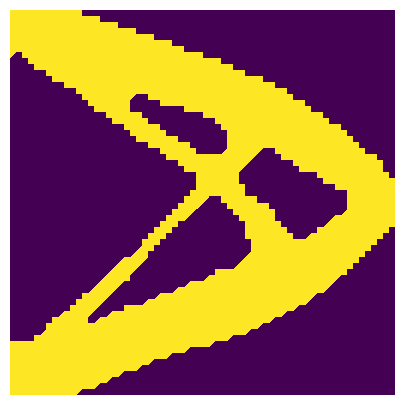

In [33]:
admmcolin.plot_control(disc=True)

In [65]:
compliance = (admmcolin.trial(0).series.compliance[1])
c1 = admmcolin.trial(0).iters.control_1[1]
c2 = admmcolin.trial(0).iters.control_2[1]
lam  = admmcolin.trial(0).iters.lam[1]
rho = admmcolin.trial(0).meta["rho_init"]
alpha = admmcolin.trial(0).meta["alpha"]
print(f"compliance = {compliance}")

compliance = 33.341451025693566


In [66]:
lagr_term = (1/len(c1)) * np.sum(c1 * lam)
print(f"lagr_term = {lagr_term}")
penal_term = (1/len(c1)) * 0.5 * rho * np.sum((c1 - c2) ** 2)
print(f"penal_term = {penal_term}")
tv_term = (1/np.sqrt(len(c1)//2)) * alpha * admmcolin.trial(0).series.tv_disc[1]
print(f"tv_term = {tv_term}")

lagr_term = 5.709474852130323
penal_term = 2.268240889515796
tv_term = 0.916727542944956


Please enter a valid value for 'which' \in {1, 2}


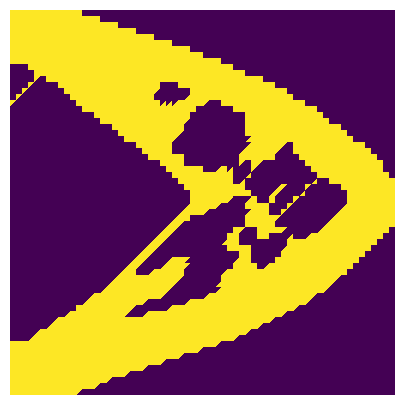

In [73]:
admmcolin.plot_control(disc=True)

### Tests for OSQP